In [ ]:
"""
The Wiener Process is a non-stationary process, in the sense that the variance increases
in each time step.
Here, I tried to reconstruct some Wiener-Process data with a band-diagonal power spectrum
and some `weirdCFM`. You will find the code for this in the text file 'custom source code'.
"""

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from initial_ideas.utils.minimization_control import *

def wiener_process(n_steps, dt=1.0):
    dW = np.random.normal(scale=np.sqrt(dt), size=n_steps)
    W = np.cumsum(dW)
    return W


class Mask(ift.LinearOperator):
    def __init__(self, domain, num_of_points_to_keep):
        self._domain = domain
        self._target = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_points_to_keep, )))
        self._capability = self.TIMES | self.ADJOINT_TIMES

        rng = np.random.default_rng()  # create a Generator instance
        self._where_to_keep = rng.integers(low=0, high=domain.shape, size=num_of_points_to_keep)

    def apply(self, x, mode):
        self._check_input(x, mode)
        # x is a field
        if mode == self.ADJOINT_TIMES:
            values = np.zeros(self._domain.shape[0])
            values[self._where_to_keep] = x.val
            return ift.Field(self._domain, values)

        elif mode == self.TIMES:
            extract = np.array(x.val)
            idcs = np.array(self._where_to_keep)
            values = extract[idcs]
            return ift.Field(self._target, values)


max_time = 1
num_of_pixels = 2048
num_of_dtps = 1500
time_domain = ift.DomainTuple.make(ift.RGSpace((num_of_pixels, ), distances=max_time/num_of_pixels))
ext_factor = 2
time_domain_ext = ift.DomainTuple.make(ift.RGSpace((num_of_pixels*ext_factor, ), distances=max_time/num_of_pixels))
data_space = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_dtps, )))


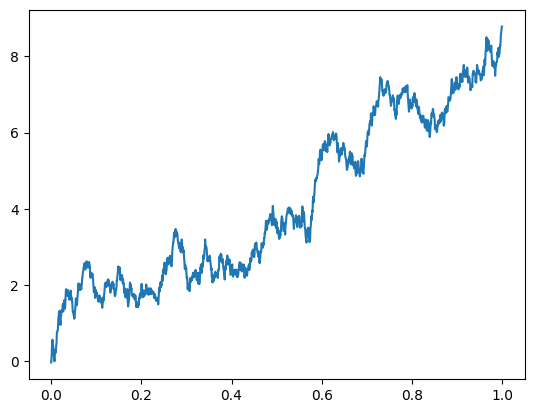

In [6]:
data = wiener_process(n_steps=num_of_dtps, dt=0.01)
time_field_data = np.linspace(0, max_time, len(data))
time_field_signal = np.linspace(0, max_time, num_of_pixels)
time_field_signal_ext = np.linspace(0, max_time*ext_factor, num_of_pixels*ext_factor)
plt.plot(time_field_data, data)
plt.show()



In [7]:
cfm_model_param = {
    "loglogavgslope": (-3, 1e-16),
    "fluctuations": (1,10),
    # "asperity": (1,1),
    "asperity": None,
    # "flexibility": (1,1),
    "flexibility": None,
    "offset_mean": 0.5,
    "offset_std": (5, 5),
             }

s = ift.SimpleCorrelatedField(time_domain_ext, **cfm_model_param, use_uniform_prior_on_fluctuations=False)
N = ift.ScalingOperator(data_space, 2, np.float64)
M = Mask(time_domain, num_of_points_to_keep=num_of_dtps)
d = ift.Field(data_space, data)
X = ift.FieldZeroPadder(time_domain, (num_of_pixels*ext_factor, )).adjoint


In [8]:
from nifty8.library.correlated_fields_simple import SimpleNonStationaryField

ns = SimpleNonStationaryField(time_domain_ext, **cfm_model_param,  second_power_spectrum=True, num_of_pixels_to_truncate=100,
                              full_matrix=True)

# likelihood_energy = ift.GaussianEnergy(d, N.inverse, sampling_dtype=np.float64) @ M @ X @ s
likelihood_energy = ift.GaussianEnergy(d, N.inverse, sampling_dtype=np.float64) @ M @ X @ ns


Constructing harmonic operator...
Constructed harmonic operator


In [9]:
posterior_samples, final_pos = ift.optimize_kl(likelihood_energy=likelihood_energy,
                                        total_iterations=6,
                                        n_samples=kl_sampling_rate,
                                        kl_minimizer=descent_finder,
                                        sampling_iteration_controller=ic_sampling_lin,
                                        nonlinear_sampling_minimizer=geoVI_sampling_minimizer,
                                        output_directory="out2",
                                        return_final_position=True,
                                        resume=False,
                                        ) # data always changes so it doesn't make sense to resume

TypeError: Domain of likelihood_energy needs to be a MultiDomain, got
DomainTuple, len: 1
* RGSpace(shape=(4096,), distances=(0.00048828125,), harmonic=False)

In [ ]:
ift.plot_priorsamples(X(ns), 3)

In [ ]:
ift.plot_priorsamples(X(s), 1)

In [ ]:
mean, var = posterior_samples.sample_stat(s)

# plt.errorbar(time_field_signal, mean.val, yerr=np.sqrt(var.val), color="b", ls="-")
plt.plot(time_field_signal, X(mean).val, color="orange", ls="-", lw=5)
plt.plot(time_field_data, data, "g-")

In [3]:

import nifty8 as ift

weird_cfm_model_param = {
    "loglogavgslope": (-3, 1e-16),
    "fluctuations": (1,10),
    # "asperity": (1,1),
    "asperity": None,
    # "flexibility": (1,1),
    "flexibility": None,
    "offset_mean": 0.5,
    "offset_std": (5, 5),
             }

test = ift.weirdCFM(time_domain_ext,**weird_cfm_model_param)

COMPUTING  0 th OPERATOR
n , distances :  4096 (0.00048828125,)


TypeError: 